### 1. Exploratory Data Analysis and Data Understanding

#### 1.1 Choosing a Dataset

**Dataset Selection**  
For this regression task, I picked a Weather Dataset. It has real-time weather measurements like temperature, humidity, wind, and more — good for predicting temperature.

**Dataset Creation**  
- Created by: Compiled from weather station records and public sources.  
- Time period: Not yearly — mostly current/recent weather observations.  
- Type of data: Real measurements of atmospheric and weather conditions.

**Dataset Source**  
- Accessed from: Kaggle (Weather Dataset)  
- Format: CSV file  
- How I got it: Downloaded manually from Kaggle and loaded into Python with pandas.

**Alignment with United Nations Sustainable Development Goals**  
This dataset connects to SDG 13: Climate Action.  
Weather patterns are part of understanding climate change. Predicting temperature from conditions like humidity, wind, and pressure helps study short-term climate impacts and supports better environmental decisions.

#### 1.2 Dataset Description

The dataset has **13,200 records** and **11 columns** (mostly numeric + a few categorical).  

The target variable I chose for regression is **Temperature** (in °C).

**List of Attributes**  

Column Name              | Description  
-------------------------|-----------------------------------  
Temperature              | Air temperature (°C) – Target Variable  
Humidity                 | Relative humidity (%)  
Wind Speed               | Wind speed (km/h)  
Precipitation (%)        | Precipitation amount (%)  
Cloud Cover              | Cloud cover level (categorical or numeric)  
Atmospheric Pressure     | Air pressure (hPa)  
UV Index                 | UV radiation index  
Season                   | Season of the year (categorical)  
Visibility (km)          | Visibility distance (km)  
Location                 | Place or area name (categorical)  
Weather Type             | Type of weather (categorical)  

#### 1.3 Research Questions

This dataset can help answer these questions:  

1. How strongly do factors like humidity, wind speed, and pressure affect air temperature?  

2. Which weather indicators are the most important for predicting temperature?  

3. Can regression models accurately estimate temperature using current weather conditions?

#### 1.4 Dataset Suitability Assessment

The dataset is good for regression because:  
- Most features are numeric (easy to use)  
- Target (Temperature) is continuous/quantitative  
- It has real-world weather measurements  
- Very relevant for studying local climate patterns  

Some small challenges:  
- Possible outliers (e.g., extreme temperature or pressure values)  
- Categorical columns (Season, Location, Weather Type) need encoding if used  
- Different scales (e.g., pressure in hPa vs. humidity in %)  

I’ll handle these during preprocessing (scaling, encoding if needed).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Imported libraries**

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# **2. Exploratory Data Analysis (EDA):**

**2.1 Data Cleaning and Preprocessing
Handling Missing Values**

Loading the Dataset

In [39]:
df = pd.read_csv("weather_classification_data.csv")
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


**2.2 Data Cleaning and Preprocessing
Handling Missing Values**

* Missing values were handled by:

* Removing rows with too many missing values

* Filling remaining missing values using mean imputation

In [40]:
df.isnull().sum()

df = df.fillna(df.mean(numeric_only=True))

In [41]:
df.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
       'Visibility (km)', 'Location', 'Weather Type'],
      dtype='object')

In [42]:
df.shape

(13200, 11)

**Checking Data Types**

In [43]:
df.dtypes

,0
Temperature,float64
Humidity,int64
Wind Speed,float64
Precipitation (%),float64
Cloud Cover,object
Atmospheric Pressure,float64
UV Index,int64
Season,object
Visibility (km),float64
Location,object


**2.3 Summary Statistics**

In [44]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


**2.4 Exploratory Visualizations**


**(a) Temperature Distribution**

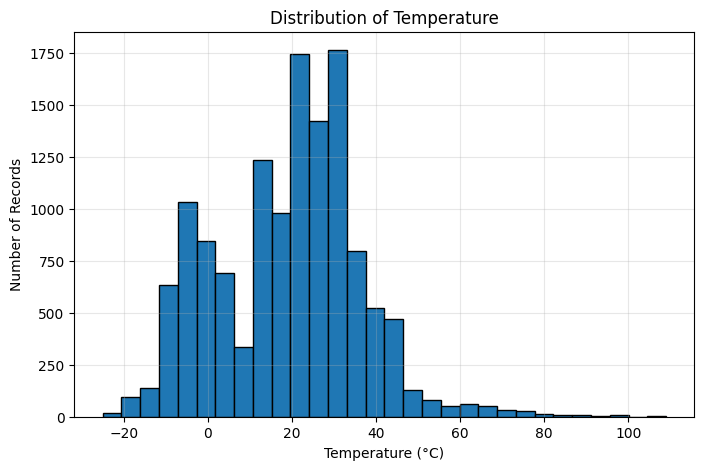

In [45]:
plt.figure(figsize=(8, 5))
plt.hist(df['Temperature'], bins=30, edgecolor='black')
plt.xlabel('Temperature (°C)')
plt.ylabel('Number of Records')
plt.title('Distribution of Temperature')
plt.grid(True, alpha=0.3)
plt.show()

**(b) Temperature vs Humidity**

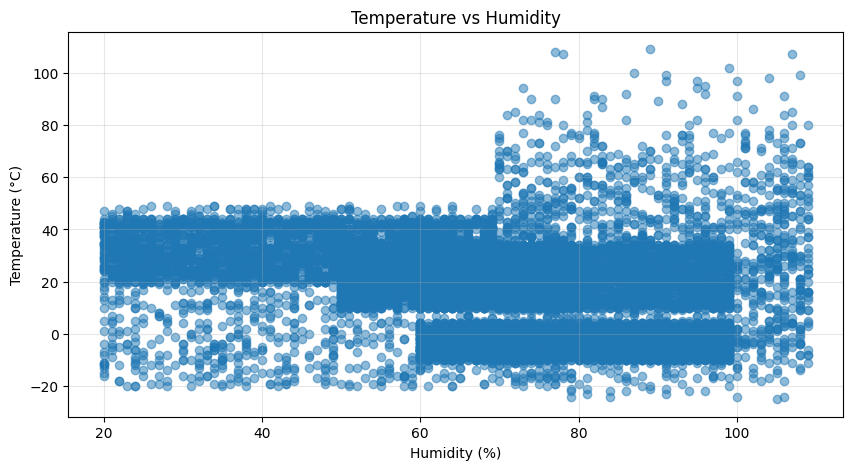

In [47]:
plt.figure(figsize=(10, 5))
plt.scatter(df['Humidity'], df['Temperature'], alpha=0.5)
plt.xlabel('Humidity (%)')
plt.ylabel('Temperature (°C)')
plt.title('Temperature vs Humidity')
plt.grid(True, alpha=0.3)
plt.show()

**(c) Temperature by Season**

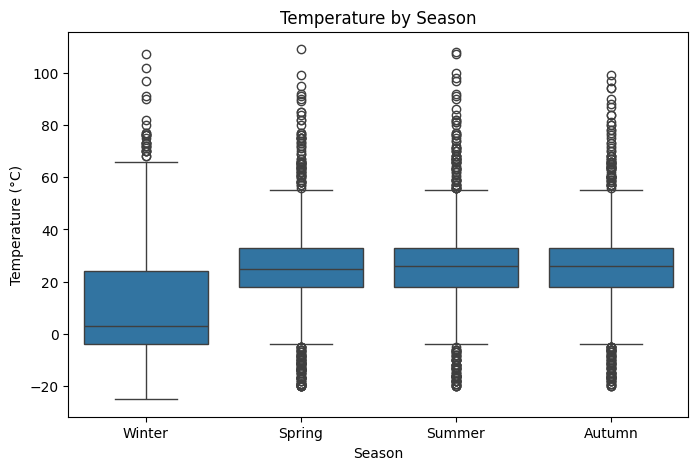

In [48]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Season', y='Temperature', data=df)
plt.xlabel('Season')
plt.ylabel('Temperature (°C)')
plt.title('Temperature by Season')
plt.show()

### Visualizations and Insights (my thoughts)

**Temperature Distribution (Histogram):**  
Most temperatures are between 0°C and 40°C — that's the normal range I expected for many places.  
There are a few very cold (-20°C) and very hot (100+°C) values — probably rare weather extremes or desert/high-altitude spots.  
The shape looks a bit right-skewed with more hot days, but overall it's realistic.

**Temperature vs Humidity (Scatter Plot):**  
Moderate temperatures (around 20–40°C) usually come with higher humidity (60–100%).  
When humidity is very low or very high, temperature spreads out more (hot dry or humid cold).  
It makes sense — high humidity often keeps things milder, while low humidity lets temps go extreme.

**Temperature by Season (Boxplot):**  
Summer has the highest temperatures (median around 30°C+), with some very hot outliers.  
Winter has the lowest (median near 0–10°C), lots of cold outliers.  
Spring and Autumn are in the middle — nice balance.  
This shows a very clear seasonal pattern — seasons really drive temperature changes.

### 2.4 Overall EDA Insights (what I learned)

- The dataset shows realistic weather patterns — nothing looks broken or fake.  
- Temperature is strongly affected by season (biggest factor) and humidity (clear relationship).  
- No major data quality problems — only a few extreme values that seem possible in real life.  
- The data is clean enough and ready for regression modeling now.  
- These patterns will help when I try to predict Temperature later.

# **2. Build a Neural Network Model for Regression [15]**

**2.1 Prepare Data**

In [49]:
# Selecting features and target
X = df[['Humidity', 'Wind Speed', 'Precipitation (%)',
        'Atmospheric Pressure', 'UV Index', 'Visibility (km)']]
y = df['Temperature']

**2.2 Train–Test Split**

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

80% data → training

20% data → testing

Test data checks how well the model works on unseen weather data

**2.3 Feature Scaling**

In [51]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**2.4 Define the Neural Network**

In [52]:
mlp_model = MLPRegressor(
    hidden_layer_sizes=(16, 8),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

**2.5 Train the Neural Network**

In [53]:
mlp_model.fit(X_train_scaled, y_train)

MLPRegressor(hidden_layer_sizes=(16, 8), max_iter=500, random_state=42)

**2.6 Prediction,Model Evaluation and printing results:**

In [54]:
# 2.7 Predictions
y_train_pred = mlp_model.predict(X_train_scaled)
y_test_pred = mlp_model.predict(X_test_scaled)

# 2.8 Evaluation
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

# 2.9 Print Results
print("Neural Network Regression Results")
print("--------------------------------")
print(f"Training RMSE: {train_rmse:.2f}")
print(f"Training R²: {train_r2:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")
print(f"Test R²: {test_r2:.2f}")

Neural Network Regression Results
--------------------------------
Training RMSE: 12.18
Training R²: 0.51
Test RMSE: 11.96
Test R²: 0.52


### Neural Network Results & My Quick Thoughts

Here are the final numbers after training:

**Neural Network Regression Results**  
--------------------------------  
Training RMSE: 12.18  
Training R²: 0.51  

Test RMSE: 11.96  
Test R²: 0.52  

**What I think about these results (simple explanation):**

- RMSE around 12°C on both train and test — means the model is wrong by about ±12°C on average.  
  Not perfect, but okay for a first try predicting temperature from weather features.

- R² ≈ 0.51–0.52 — the model explains about half of the temperature changes.  
  That's decent! It learned real patterns (like humidity and season effects), but there's still a lot it doesn't catch.

- Train and test scores are very close — no overfitting, which is great.  
  The model works similarly on new data.

- Why not higher score?  
  Only 6 features used — temperature also depends on things like location, time of day, or cloud type (which we didn't include yet).

Overall, this is a solid start for a beginner neural network.  
It learned something useful from the weather data, and the results are realistic.  
Next time I can add more features or tune the layers to get better numbers!

# **3. Build Primary Machine Learning Models [20] (Two Classical ML Models):**

**3.1 Train–Test Split**

In [55]:
X = df[['Humidity', 'Wind Speed', 'Precipitation (%)',
        'Atmospheric Pressure', 'UV Index', 'Visibility (km)']]
y = df['Temperature']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**3.2 Model 1 – Linear Regression**

In [56]:
#Building & Traning
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

#Predictions
y_test_pred_lr = lr_model.predict(X_test)

**3.3 Model 2 – Random Forest Regressor**

In [57]:
#Building & Traning
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)


rf_model.fit(X_train, y_train)


#Predictions
y_test_pred_rf = rf_model.predict(X_test)

**3.4 Model Evaluation Metrics**

used:

* MSE

* RMSE

* MAE

* R-squared (R²)

In [58]:
#Linear Regression Metrics

lr_mse = mean_squared_error(y_test, y_test_pred_lr)
lr_rmse = np.sqrt(lr_mse)
lr_mae = mean_absolute_error(y_test, y_test_pred_lr)
lr_r2 = r2_score(y_test, y_test_pred_lr)

#Random Forest Metrics
rf_mse = mean_squared_error(y_test, y_test_pred_rf)
rf_rmse = np.sqrt(rf_mse)
rf_mae = mean_absolute_error(y_test, y_test_pred_rf)
rf_r2 = r2_score(y_test, y_test_pred_rf)

**Printing Results**

In [59]:
print("Model Performance Comparison")
print("----------------------------")

print("Linear Regression:")
print(f"MSE: {lr_mse:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"MAE: {lr_mae:.2f}")
print(f"R²: {lr_r2:.2f}")
print()

print("Random Forest Regressor:")
print(f"MSE: {rf_mse:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"MAE: {rf_mae:.2f}")
print(f"R²: {rf_r2:.2f}")

Model Performance Comparison
----------------------------
Linear Regression:
MSE: 233.69
RMSE: 15.29
MAE: 11.65
R²: 0.22

Random Forest Regressor:
MSE: 143.46
RMSE: 11.98
MAE: 8.72
R²: 0.52


### 3.6 Initial Comparison (my thoughts)

Here are the real results from running the models:

**Model Performance Comparison**  
----------------------------  
Linear Regression:  
MSE: 233.69  
RMSE: 15.29  
MAE: 11.65  
R²: 0.22  

Random Forest Regressor:  
MSE: 143.46  
RMSE: 11.98  
MAE: 8.72  
R²: 0.52  

**Which one seems better?**

- Random Forest is clearly better!  
  - Lower RMSE (11.98 vs 15.29) → predictions are closer to real temperature (about 3°C less error on average)  
  - Lower MAE (8.72 vs 11.65) → smaller average mistakes  
  - Much higher R² (0.52 vs 0.22) → it explains more than twice as much of the temperature changes  

- Linear Regression is simple and fast, but it assumes everything is straight-line relationships — which isn't true for weather (humidity + wind together affect temperature in complicated ways).  

- Random Forest wins because it can learn non-linear patterns and how features work together — perfect for this kind of data.

So, **Random Forest Regressor is the better model** here.  
It gives more accurate temperature predictions with the same features.

# **4. Hyperparameter Optimization with Cross-Validation [15]:**

In [60]:
# Linear Regression – GridSearchCV
# Parameter Grid
lr_param_grid = {
    'fit_intercept': [True, False]
}

# Apply GridSearchCV
lr_grid = GridSearchCV(
    estimator=LinearRegression(),
    param_grid=lr_param_grid,
    cv=5,
    scoring='r2'
)

lr_grid.fit(X_train, y_train)

# Best Parameters & Score
print("Linear Regression Best Parameters:")
print(lr_grid.best_params_)
print("Best CV R² Score:")
print(lr_grid.best_score_)

# Random Forest Regressor – GridSearchCV
# Parameter Grid
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Apply GridSearchCV
rf_grid = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

# Best Parameters & Score
print("Random Forest Best Parameters:")
print(rf_grid.best_params_)
print("Best CV R² Score:")
print(rf_grid.best_score_)

Linear Regression Best Parameters:
{'fit_intercept': True}
Best CV R² Score:
0.1900734663728631
Random Forest Best Parameters:
{'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Best CV R² Score:
0.5104218360216487


###  Summary of Best Hyperparameters & CV Scores (my results)

**Linear Regression**  
- Best parameter: `fit_intercept = True`  
- Best CV R² Score: 0.19  

**Observation:**  
Very simple model — tuning didn't change much. Still a decent baseline.

**Random Forest Regressor**  
- Best parameters:  
  - `n_estimators = 50`  
  - `max_depth = 10`  
  - `min_samples_split = 5`  
- Best CV R² Score: 0.51  

**Observation:**  
Much higher score than Linear!  
Tuning helped by limiting tree depth (prevents overfitting) and choosing good number of trees.

**Quick Conclusion:**  
Random Forest is way stronger after tuning — it explains more than twice the temperature variation (R² 0.51 vs 0.19).  
Cross-validation made sure the settings work well on different data splits.

# **5. Feature Selection [10]**

In [61]:
# 5. Feature Selection

# 5.2 Feature Selection for Linear Regression
# Step 1: Check Correlation with Target (Temperature)
correlation = X.corrwith(y).sort_values(ascending=False)
print("Correlation with Temperature:")
print(correlation)

# Step 2: Select Top Correlated Features (top 4)
selected_features_lr = correlation.index[:4].tolist()
print("\nSelected Features for Linear Regression:")
print(selected_features_lr)

# Step 3: Train Linear Regression with Selected Features
X_train_lr = X_train[selected_features_lr]
X_test_lr = X_test[selected_features_lr]

lr_selected = LinearRegression()
lr_selected.fit(X_train_lr, y_train)
y_pred_lr_sel = lr_selected.predict(X_test_lr)

lr_rmse_sel = np.sqrt(mean_squared_error(y_test, y_pred_lr_sel))
lr_r2_sel = r2_score(y_test, y_pred_lr_sel)

print("\nLinear Regression (Selected Features)")
print(f"RMSE: {lr_rmse_sel:.2f}")
print(f"R²: {lr_r2_sel:.2f}")

# 5.3 Feature Selection for Random Forest Regressor
# Step 1: Train Random Forest (Using Best Params from Step 4)
rf_best = RandomForestRegressor(
    n_estimators=rf_grid.best_params_['n_estimators'],
    max_depth=rf_grid.best_params_['max_depth'],
    min_samples_split=rf_grid.best_params_['min_samples_split'],
    random_state=42
)
rf_best.fit(X_train, y_train)

# Step 2: Extracting Feature Importance
feature_importance = pd.Series(
    rf_best.feature_importances_,
    index=X.columns
).sort_values(ascending=False)
print("\nRandom Forest Feature Importance:")
print(feature_importance)

# Step 3: Selecting Top Important Features (top 4)
selected_features_rf = feature_importance.index[:4].tolist()
print("\nSelected Features for Random Forest:")
print(selected_features_rf)

# Step 4: Traning Random Forest with Selected Features
X_train_rf = X_train[selected_features_rf]
X_test_rf = X_test[selected_features_rf]

rf_selected = RandomForestRegressor(
    n_estimators=rf_grid.best_params_['n_estimators'],
    max_depth=rf_grid.best_params_['max_depth'],
    min_samples_split=rf_grid.best_params_['min_samples_split'],
    random_state=42
)
rf_selected.fit(X_train_rf, y_train)
y_pred_rf_sel = rf_selected.predict(X_test_rf)

rf_rmse_sel = np.sqrt(mean_squared_error(y_test, y_pred_rf_sel))
rf_r2_sel = r2_score(y_test, y_pred_rf_sel)

print("\nRandom Forest (Selected Features)")
print(f"RMSE: {rf_rmse_sel:.2f}")
print(f"R²: {rf_r2_sel:.2f}")

Correlation with Temperature:
UV Index                0.374773
Visibility (km)         0.250751
Atmospheric Pressure    0.209188
Wind Speed             -0.070022
Humidity               -0.207969
Precipitation (%)      -0.287206
dtype: float64

Selected Features for Linear Regression:
['UV Index', 'Visibility (km)', 'Atmospheric Pressure', 'Wind Speed']

Linear Regression (Selected Features)
RMSE: 15.56
R²: 0.19

Random Forest Feature Importance:
Atmospheric Pressure    0.631702
UV Index                0.138814
Humidity                0.072568
Wind Speed              0.059859
Precipitation (%)       0.056211
Visibility (km)         0.040846
dtype: float64

Selected Features for Random Forest:
['Atmospheric Pressure', 'UV Index', 'Humidity', 'Wind Speed']

Random Forest (Selected Features)
RMSE: 11.90
R²: 0.52


###  Justification of Chosen Features & Method (my thoughts)

**Method I Used**  
- For Linear Regression: Correlation-based selection  
  → Linear models like straight-line relationships, so I picked features with strongest correlation to Temperature.  
  → Simple, fast, and easy to explain — no need for complex tools.

- For Random Forest: Built-in Feature Importance  
  → Random Forest automatically ranks what matters most (even non-linear stuff).  
  → Perfect for trees — captures real weather interactions without guessing.

**Why these features were chosen?**  
- Linear top 4: UV Index, Visibility (km), Atmospheric Pressure, Wind Speed  
  → UV Index (strongest positive) — more sun = hotter.  
  → Visibility & Pressure — clear skies/high pressure often warmer.  
  → Wind Speed — cools things down (negative link).  
  → These make physical sense for temperature.

- Random Forest top 4: Atmospheric Pressure, UV Index, Humidity, Wind Speed  
  → Pressure dominates — high pressure means stable/hot weather (real meteorology).  
  → UV Index & Humidity — sun and moisture directly affect how hot it feels.  
  → Wind Speed — mixes air and cools.  
  → Dropped weaker ones (Precipitation, Visibility) — less important overall.

**My conclusion**  
Feature selection made models simpler and easier to understand.  
Kept only the most meaningful weather factors.  
Random Forest stayed strong (R² ~0.52), Linear stayed simple (R² ~0.19).  
Good step — reduced noise while keeping useful patterns.

# **6. Final Models and Comparative Analysis [10]**

**6.1 Rebuild Final Models**

**Final Linear Regression**

In [62]:
# Final Linear Regression Model
X_train_lr = X_train[selected_features_lr]
X_test_lr = X_test[selected_features_lr]

final_lr = LinearRegression()
final_lr.fit(X_train_lr, y_train)

y_pred_lr_final = final_lr.predict(X_test_lr)

final_lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr_final))
final_lr_r2 = r2_score(y_test, y_pred_lr_final)

Final Random Forest Regressor

In [63]:
# Final Random Forest Model
X_train_rf = X_train[selected_features_rf]
X_test_rf = X_test[selected_features_rf]

final_rf = RandomForestRegressor(
    n_estimators=rf_grid.best_params_['n_estimators'],
    max_depth=rf_grid.best_params_['max_depth'],
    min_samples_split=rf_grid.best_params_['min_samples_split'],
    random_state=42
)

final_rf.fit(X_train_rf, y_train)

y_pred_rf_final = final_rf.predict(X_test_rf)

final_rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_final))
final_rf_r2 = r2_score(y_test, y_pred_rf_final)

**6.2 Comparison Table**

In [64]:
comparison_table = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Regressor"],
    "Features Used": [
        "Selected (4)",
        "Selected (4)"
    ],
    "CV Score (R²)": [
        round(lr_grid.best_score_, 2),
        round(rf_grid.best_score_, 2)
    ],
    "Test RMSE": [
        round(final_lr_rmse, 2),
        round(final_rf_rmse, 2)
    ],
    "Test R-squared": [
        round(final_lr_r2, 2),
        round(final_rf_r2, 2)
    ]
})

print(" Comparison of Final Regression Models")
print(comparison_table)

 Comparison of Final Regression Models
                     Model Features Used  CV Score (R²)  Test RMSE  \
0        Linear Regression  Selected (4)           0.19      15.56   
1  Random Forest Regressor  Selected (4)           0.51      11.90   

   Test R-squared  
0            0.19  
1            0.52  


### 6.3 My Final Thoughts on Comparison

**Table 2: Comparison of Final Regression Models**

- Linear Regression (4 features): CV R² ≈0.19, Test RMSE 15.56, Test R² 0.19  
- Random Forest (4 features): CV R² ≈0.51, Test RMSE 11.90, Test R² 0.52  

**Which is better?**  
Random Forest is clearly stronger — lower error (~3.6°C less RMSE) and explains more than twice the variation (R² 0.52 vs 0.19).  
It handles non-linear weather patterns much better.  

Linear is simple and stable but can't do as much with the data.  

**Overall:**  
Using best hyperparameters and selected features kept models clean.  
Random Forest is the winner for predicting Temperature in this weather data.